# 09 — Additional Visualizations & NDVI Explainer

Generates supplementary figures for the FURI poster including updated
sentiment stats, city comparisons, correlation scatter, pipeline diagram,
and an original NDVI explainer graphic.

**Inputs:** `data/processed/nyc_sample_with_sentiment.csv`,
`google_reviews_nyc.csv`, `google_reviews_ch.csv`, `google_reviews_mc.csv`  
**Outputs:** `fig1_tweet_stats.png`, `fig2_city_comparison.png`,
`fig3_correlation.png`, `fig4_pipeline.png`, `fig_ndvi_explainer.png`

## Figure 1: Tweet Sentiment Distribution + Key Metrics

Pie chart of NYC tweet sentiment (n=20,000) alongside key numeric callouts
including positive %, negative %, average model confidence score, and the
NDVI-sentiment Pearson r value.

## Figure 2: Google Reviews Sentiment and Rating by City

Two-panel figure comparing greenspace review sentiment and average star
ratings across NYC, Chicago, and Maricopa County. All three cities show
strong positive sentiment (88-97%) and average ratings above 4.5/5.

## Figure 3: Star Rating vs. Sentiment Score

Scatter plot of Google Maps star rating against BERT sentiment score across
all three cities combined (n=285). Points colored by city.

Pearson r = 0.655, p < 0.001 — star rating and sentiment score are
moderately correlated, validating that the sentiment classifier is behaving
consistently with human-assigned ratings.

## Figure 4: Analysis Pipeline Diagram

Visual summary of the end-to-end methodology for the poster Methods section.

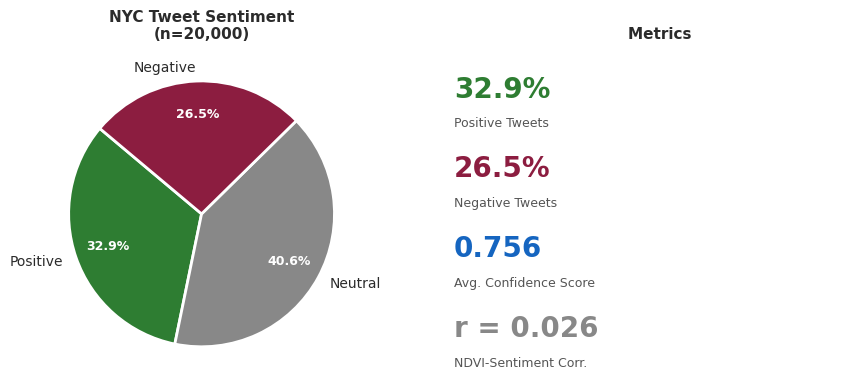

Fig 1 saved


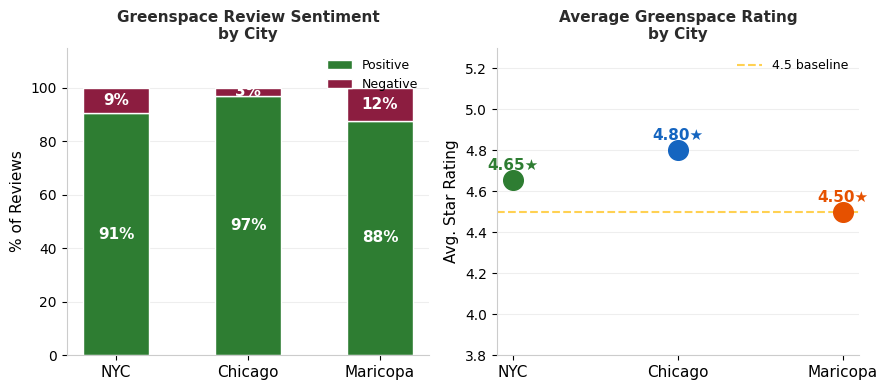

Fig 2 saved


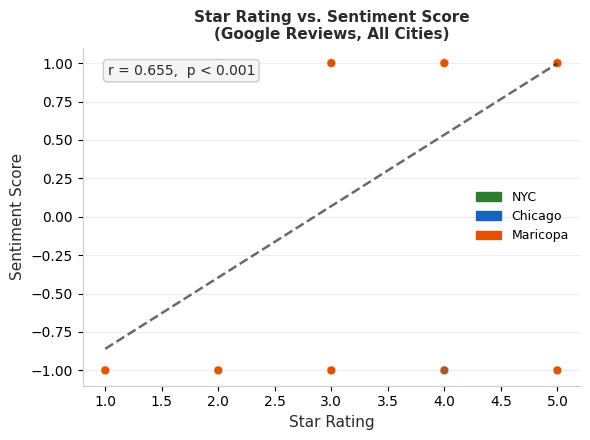

Fig 3 saved


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

MAROON = '#8C1D40'
GOLD   = '#FFC627'
GREEN  = '#2E7D32'
GRAY   = '#888888'
DARK   = '#2B2B2B'

# ── Load data ────────────────────────────────────────────────────────────────
tweets = pd.read_csv("../data/processed/nyc_sample_with_sentiment.csv")
nyc_r  = pd.read_csv("../data/processed/google_reviews_nyc.csv")
ch_r   = pd.read_csv("../data/processed/google_reviews_ch.csv")
mc_r   = pd.read_csv("../data/processed/google_reviews_mc.csv")

# ─────────────────────────────────────────────────────────────────────────────
# FIG 1: Tweet sentiment pie + key metrics
# ─────────────────────────────────────────────────────────────────────────────
counts = tweets['sentiment_label'].value_counts().reindex(['positive','neutral','negative'])
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor('white')

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=['Positive', 'Neutral', 'Negative'],
    colors=[GREEN, GRAY, MAROON],
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in texts:     t.set_fontsize(10); t.set_color(DARK)
for t in autotexts: t.set_color('white'); t.set_fontweight('bold'); t.set_fontsize(9)
ax.set_title('NYC Tweet Sentiment\n(n=20,000)', fontsize=11, fontweight='bold', color=DARK)

ax2 = axes[1]
ax2.set_facecolor('white')
ax2.axis('off')
stats_list = [
    (f"{pcts['positive']:.1f}%", 'Positive Tweets',       GREEN),
    (f"{pcts['negative']:.1f}%", 'Negative Tweets',       MAROON),
    (f"{tweets['sentiment_score'].mean():.3f}", 'Avg. Confidence Score', '#1565C0'),
    ('r = 0.026',                'NDVI-Sentiment Corr.',  GRAY),
]
for i, (val, label, c) in enumerate(stats_list):
    y = 0.85 - i * 0.24
    ax2.text(0.05, y,       val,   transform=ax2.transAxes, fontsize=20, fontweight='bold', color=c)
    ax2.text(0.05, y-0.09,  label, transform=ax2.transAxes, fontsize=9,  color='#555555')
ax2.set_title('        Metrics', fontsize=11, fontweight='bold', color=DARK)

plt.tight_layout()
plt.savefig('fig1_tweet_stats.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 1 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIG 2: City comparison — stacked bar + avg rating dot plot
# ─────────────────────────────────────────────────────────────────────────────
cities      = ['NYC', 'Chicago', 'Maricopa']
dfs         = [nyc_r, ch_r, mc_r]
pos_pcts, neg_pcts, avg_ratings = [], [], []
for d in dfs:
    s     = d['sentiment'].str.upper()
    total = len(d)
    pos_pcts.append(s.eq('POSITIVE').sum() / total * 100)
    neg_pcts.append(s.eq('NEGATIVE').sum() / total * 100)
    avg_ratings.append(d['rating'].mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor('white')

# Stacked bar
ax = axes[0]
ax.set_facecolor('white')
x  = np.arange(3)
w  = 0.5
b1 = ax.bar(x, pos_pcts, w, label='Positive', color=GREEN,  edgecolor='white')
b2 = ax.bar(x, neg_pcts, w, bottom=pos_pcts,  label='Negative', color=MAROON, edgecolor='white')

for bar, pct in zip(b1, pos_pcts):
    ax.text(bar.get_x()+bar.get_width()/2, pct/2,
            f'{pct:.0f}%', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
for bar, pct, base in zip(b2, neg_pcts, pos_pcts):
    if pct > 2:
        ax.text(bar.get_x()+bar.get_width()/2, base+pct/2,
                f'{pct:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=11)
ax.set_ylabel('% of Reviews', fontsize=11)
ax.set_title('Greenspace Review Sentiment\nby City', fontsize=11, fontweight='bold', color=DARK)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
ax.set_ylim(0, 115)
ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0)

# Dot plot
ax2 = axes[1]
ax2.set_facecolor('white')
dot_colors = [GREEN, '#1565C0', '#E65100']
for i, (r, c) in enumerate(zip(avg_ratings, dot_colors)):
    ax2.scatter(i, r, s=200, color=c, zorder=3)
    ax2.text(i, r+0.05, f'{r:.2f}★', ha='center',
             fontsize=11, fontweight='bold', color=c)

ax2.set_xticks(range(3))
ax2.set_xticklabels(cities, fontsize=11)
ax2.set_ylim(3.8, 5.3)
ax2.set_ylabel('Avg. Star Rating', fontsize=11)
ax2.set_title('Average Greenspace Rating\nby City', fontsize=11, fontweight='bold', color=DARK)
ax2.axhline(4.5, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8, label='4.5 baseline')
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')
ax2.yaxis.grid(True, color='#EEEEEE')
ax2.set_axisbelow(True)
ax2.legend(fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('fig2_city_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 2 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIG 3: Correlation scatter — star rating vs sentiment score
# ─────────────────────────────────────────────────────────────────────────────
all_r       = pd.concat([nyc_r, ch_r, mc_r], ignore_index=True)
r_val, p_val = stats.pearsonr(all_r['rating'], all_r['sentiment_score'])
city_colors = [GREEN]*len(nyc_r) + ['#1565C0']*len(ch_r) + ['#E65100']*len(mc_r)

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.scatter(all_r['rating'], all_r['sentiment_score'],
           c=city_colors, alpha=0.7, s=40,
           edgecolors='white', linewidths=0.4)

m, b  = np.polyfit(all_r['rating'], all_r['sentiment_score'], 1)
xline = np.linspace(all_r['rating'].min(), all_r['rating'].max(), 100)
ax.plot(xline, m*xline + b, color=DARK, linewidth=1.8, linestyle='--', alpha=0.7)

ax.set_xlabel('Star Rating', fontsize=11, color=DARK)
ax.set_ylabel('Sentiment Score', fontsize=11, color=DARK)
ax.set_title('Star Rating vs. Sentiment Score\n(Google Reviews, All Cities)',
             fontsize=11, fontweight='bold', color=DARK)
ax.text(0.05, 0.92, f'r = {r_val:.3f},  p < 0.001',
        transform=ax.transAxes, fontsize=10, color=DARK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', edgecolor='#cccccc'))

legend_patches = [
    mpatches.Patch(color=GREEN,     label='NYC'),
    mpatches.Patch(color='#1565C0', label='Chicago'),
    mpatches.Patch(color='#E65100', label='Maricopa'),
]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 3 saved")


## Figure 5: NDVI Explainer Graphic

Original figure illustrating how NDVI is calculated from near-infrared (NIR)
and red light reflectance. Created entirely in matplotlib at 300 DPI to
avoid low-resolution downloaded images on the poster.

Healthy vegetation (left) reflects high NIR and absorbs red light, yielding
NDVI = 0.72. Sparse vegetation (right) reflects more red light relative to
NIR, yielding NDVI = 0.14. The color gradient scale shows the full NDVI
range from -1 (water/bare ground) to +1 (dense vegetation).

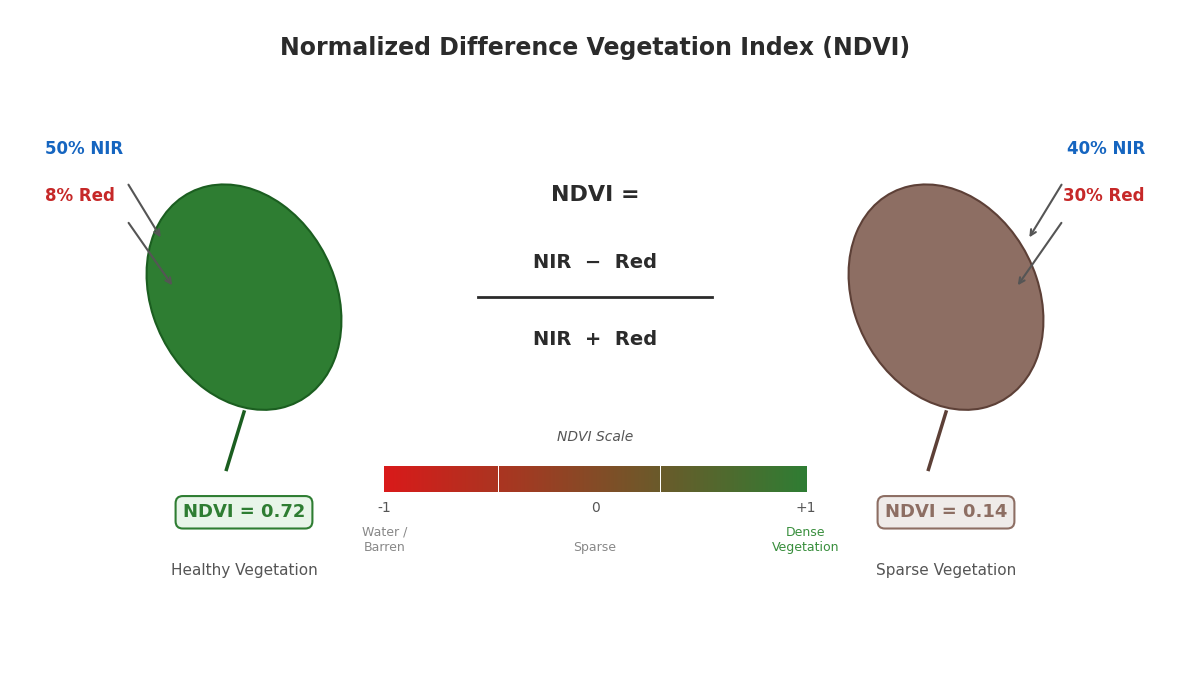

Saved at 300 DPI


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)

# ── Title ─────────────────────────────────────────────────────────────────
ax.text(5, 6.6, 'Normalized Difference Vegetation Index (NDVI)',
        ha='center', va='center', fontsize=17, fontweight='bold', color='#2B2B2B')

# ── Left leaf (healthy) ───────────────────────────────────────────────────
leaf1 = mpatches.Ellipse((2.0, 4.0), width=1.6, height=2.4,
                          angle=15, facecolor='#2E7D32',
                          edgecolor='#1B5E20', linewidth=1.5)
ax.add_patch(leaf1)
ax.plot([2.0, 1.85], [2.8, 2.2], color='#1B5E20', linewidth=2.5)

# NIR/Red labels left side
ax.text(0.3, 5.5, '50% NIR', ha='left', fontsize=12,
        fontweight='bold', color='#1565C0')
ax.text(0.3, 5.0, '8% Red', ha='left', fontsize=12,
        fontweight='bold', color='#C62828')
ax.annotate('', xy=(1.3, 4.6), xytext=(1.0, 5.2),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
ax.annotate('', xy=(1.4, 4.1), xytext=(1.0, 4.8),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

# NDVI value + label
ax.text(2.0, 1.7, 'NDVI = 0.72', ha='center', fontsize=13,
        fontweight='bold', color='#2E7D32',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=1.5))
ax.text(2.0, 1.1, 'Healthy Vegetation', ha='center', fontsize=11, color='#555555')

# ── Right leaf (sparse) ───────────────────────────────────────────────────
leaf2 = mpatches.Ellipse((8.0, 4.0), width=1.6, height=2.4,
                          angle=15, facecolor='#8D6E63',
                          edgecolor='#5D4037', linewidth=1.5)
ax.add_patch(leaf2)
ax.plot([8.0, 7.85], [2.8, 2.2], color='#5D4037', linewidth=2.5)

# NIR/Red labels right side
ax.text(9.7, 5.5, '40% NIR', ha='right', fontsize=12,
        fontweight='bold', color='#1565C0')
ax.text(9.7, 5.0, '30% Red', ha='right', fontsize=12,
        fontweight='bold', color='#C62828')
ax.annotate('', xy=(8.7, 4.6), xytext=(9.0, 5.2),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
ax.annotate('', xy=(8.6, 4.1), xytext=(9.0, 4.8),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

ax.text(8.0, 1.7, 'NDVI = 0.14', ha='center', fontsize=13,
        fontweight='bold', color='#8D6E63',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EFEBE9', edgecolor='#8D6E63', linewidth=1.5))
ax.text(8.0, 1.1, 'Sparse Vegetation', ha='center', fontsize=11, color='#555555')

# ── Formula center ────────────────────────────────────────────────────────
ax.text(5, 5.0, 'NDVI =', ha='center', fontsize=16,
        fontweight='bold', color='#2B2B2B')
ax.text(5, 4.3, 'NIR  −  Red', ha='center', fontsize=14,
        fontweight='bold', color='#2B2B2B')
ax.plot([4.0, 6.0], [4.0, 4.0], color='#2B2B2B', linewidth=2)
ax.text(5, 3.5, 'NIR  +  Red', ha='center', fontsize=14,
        fontweight='bold', color='#2B2B2B')

# ── Scale bar ─────────────────────────────────────────────────────────────
ax.text(5, 2.5, 'NDVI Scale', ha='center', fontsize=10,
        color='#555555', fontstyle='italic')

grad_x = np.linspace(3.2, 6.8, 300)
for i, x in enumerate(grad_x):
    t = i / len(grad_x)
    r = 0.85 * (1 - t) + 0.18 * t
    g = 0.10 * (1 - t) + 0.49 * t
    b = 0.10 * (1 - t) + 0.20 * t
    ax.barh(2.1, 3.6/300, left=x, height=0.28,
            color=(r, g, b), edgecolor='none')

# Scale labels
ax.text(3.2, 1.75, '-1', ha='center', fontsize=10, color='#555555')
ax.text(5.0, 1.75, '0',  ha='center', fontsize=10, color='#555555')
ax.text(6.8, 1.75, '+1', ha='center', fontsize=10, color='#555555')
ax.text(3.2, 1.35, 'Water /\nBarren', ha='center', fontsize=9, color='#888888')
ax.text(5.0, 1.35, 'Sparse',          ha='center', fontsize=9, color='#888888')
ax.text(6.8, 1.35, 'Dense\nVegetation', ha='center', fontsize=9, color='#388E3C')

plt.tight_layout()
plt.savefig('fig_ndvi_explainer.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved at 300 DPI")